In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.multitest import multipletests
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform


In [18]:

def add_significance_to_df(df):
    """
    Add empirical p-values, q-values, and z-scores for cosine_distance_means.

    Null rows are those with perturbation == 'control_vs_control'.
    Multiple testing correction is applied ONLY to non-null observations,
    not to the rows used to generate the null distribution.
    """
    df = df.copy()

    null_mask = df["perturbation"] == "control_vs_control"
    obs_mask = ~null_mask

    null_cosine = df.loc[null_mask, "cosine_distance_means"].to_numpy()
    n_null = len(null_cosine)

    if n_null < 5:
        raise ValueError("Too few null samples to estimate significance reliably.")

    null_mean = np.mean(null_cosine)
    null_std = np.std(null_cosine, ddof=1) if n_null > 1 else np.nan

    # initialize columns
    df["z_cosine"] = np.nan
    df["pval_cosine"] = np.nan
    df["qval_cosine"] = np.nan

    # z-scores for observed perturbations only
    obs_values = df.loc[obs_mask, "cosine_distance_means"].to_numpy()
    df.loc[obs_mask, "z_cosine"] = (obs_values - null_mean) / null_std

    # empirical one-sided p-values for observed perturbations only
    def empirical_pval(x):
        ge = np.sum(null_cosine >= x)
        return (ge + 1.0) / (n_null + 1.0)

    obs_pvals = np.array([empirical_pval(x) for x in obs_values])
    df.loc[obs_mask, "pval_cosine"] = obs_pvals

    # BH correction only across observed perturbation rows
    _, obs_qvals, _, _ = multipletests(obs_pvals, method="fdr_bh")
    df.loc[obs_mask, "qval_cosine"] = obs_qvals

    return df

In [19]:
def concatenate_drug_files(
    drug_folder: str | Path,
    pattern: str = "*_pca_cosineRes_100Pcs.csv",
    output_file: str = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Concatenate all CSV files for a specific drug.
    
    Parameters:
    -----------
    drug_folder : str or Path
        Path to drug folder containing CSV files
    pattern : str
        Pattern to match CSV files
    output_file : str, optional
        Path to save concatenated file
    verbose : bool
        Print progress
    
    Returns:
    --------
    df : pd.DataFrame
        Concatenated DataFrame
    """
    
    drug_folder = Path(drug_folder)
    drug_name = drug_folder.name
    
    # Find all matching CSV files
    csv_files = sorted(drug_folder.glob(pattern))
    
    if len(csv_files) == 0:
        raise FileNotFoundError(f"No files matching '{pattern}' found in {drug_folder}")
    
    if verbose:
        print(f"\nProcessing drug: {drug_name}")
        print(f"  Found {len(csv_files)} CSV files")
    
    # Read and concatenate
    dfs = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        
        # Add drug column if not present
        if 'drug' not in df.columns:
            df['drug'] = drug_name
        
        # Add source file info
        df['source_file'] = csv_file.name
        
        dfs.append(df)
    
    # Concatenate
    df_combined = pd.concat(dfs, ignore_index=True)
    print(df_combined)
    if verbose:
        n_controls = (df_combined['perturbation'] == 'control_vs_control').sum()
        n_perts = (df_combined['perturbation'] != 'control_vs_control').sum()
        print(f"  Total rows: {len(df_combined):,}")
        print(f"    Control samples: {n_controls:,}")
        print(f"    Perturbations: {n_perts:,}")
    
    #df_combined = add_significance_to_df(df_combined)
    
    print(df_combined)
    # Save if requested
    if output_file is not None:
        output_file = Path(output_file)
        df_combined.to_csv(output_file, index=False)
        if verbose:
            print(f"  ✓ Saved to: {output_file}")
    
    return df_combined


In [20]:
def concatenate_all_drugs(
    root_folder: str | Path,
    output_dir: str | Path = "./concatenated_results",
    pattern: str = "*_pca_cosineRes_100Pcs.csv",
    save_individual: bool = True,
    verbose: bool = True
) -> Dict[str, pd.DataFrame]:
    """
    Concatenate CSV files for all drugs in root folder.
    
    Parameters:
    -----------
    root_folder : str or Path
        Root folder containing drug subfolders
    output_dir : str or Path
        Directory to save concatenated files
    pattern : str
        Pattern to match CSV files
    save_individual : bool
        Whether to save individual concatenated files per drug
    verbose : bool
        Print progress
    
    Returns:
    --------
    drug_dfs : dict
        Dictionary mapping drug names to DataFrames
    """
    
    root_folder = Path(root_folder)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    if verbose:
        print("="*60)
        print("CONCATENATING CSV FILES FOR ALL DRUGS")
        print("="*60)
    
    # Find all drug folders (folders containing matching CSV files)
    drug_folders = []
    for folder in root_folder.iterdir():
        if folder.is_dir():
            csv_files = list(folder.glob(pattern))
            if len(csv_files) > 0:
                drug_folders.append(folder)
    
    if verbose:
        print(f"\nFound {len(drug_folders)} drug folders with matching files")
    
    drug_dfs = {}
    
    for drug_folder in sorted(drug_folders):
        drug_name = drug_folder.name
        
        output_file = output_dir / f"{drug_name}_combined.csv" if save_individual else None
        
        try:
            df = concatenate_drug_files(
                drug_folder=drug_folder,
                pattern=pattern,
                output_file=output_file,
                verbose=verbose
            )
            drug_dfs[drug_name] = df
        except Exception as e:
            print(f"  ERROR processing {drug_name}: {e}")
            continue
    
    if verbose:
        print("\n" + "="*60)
        print(f"✓ Successfully processed {len(drug_dfs)} drugs")
        print("="*60)
    
    return drug_dfs



In [21]:
drug_dfs = concatenate_all_drugs(
    root_folder="/home/beraslan/Projects/ChemoGeneticScreens/DATA/",
    output_dir="/home/beraslan/Projects/ChemoGeneticScreens/PerSignificance100PCs",
)

CONCATENATING CSV FILES FOR ALL DRUGS

Found 16 drug folders with matching files

Processing drug: AR-A014418
  Found 24 CSV files
            perturbation  n_pert  n_ctrl_mean  n_ctrl_null_pool  \
0                   A1BG    2540        50000            221000   
1                   AASS     923        50000            221000   
2                  ABCB6    1442        50000            221000   
3                  ABCC5    1086        50000            221000   
4                  ABCF1    1134        50000            221000   
...                  ...     ...          ...               ...   
9255  control_vs_control    3000        50000            221000   
9256  control_vs_control    3000        50000            221000   
9257  control_vs_control    3000        50000            221000   
9258  control_vs_control    3000        50000            221000   
9259  control_vs_control    3000        50000            221000   

      cosine_distance_means  z_cosine  pval_cosine  qval_cosine 

In [22]:
def plot_cosine_distance_histogram(
    df: pd.DataFrame,
    drug_name: str,
    qval_threshold: float = 0.15,
    bins: int = 50,
    figsize: Tuple[int, int] = (10, 6),
    output_path: str = None,
    show_plot: bool = True
):
    """
    Plot histogram of cosine distances with controls and perturbations colored separately.

    Updates:
    - Also marks the median of the perturbation distribution
    - Does not show the number of null/control data points in the legend
    """

    # Separate controls and perturbations
    control_mask = df["perturbation"] == "control_vs_control"
    control_data = df.loc[control_mask, "cosine_distance_means"].dropna()
    pert_data = df.loc[~control_mask, "cosine_distance_means"].dropna()

    # Count significant perturbations
    pert_df = df.loc[~control_mask].copy()
    n_total_perts = pert_df["perturbation"].nunique()

    if "qval_cosine" in pert_df.columns:
        # count unique significant perturbations
        sig_perts = pert_df.loc[pert_df["qval_cosine"] < qval_threshold, "perturbation"].dropna().unique()
        n_significant = len(sig_perts)
        pct_significant = (n_significant / n_total_perts * 100) if n_total_perts > 0 else 0
    else:
        n_significant = 0
        pct_significant = 0

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot histograms
    ax.hist(
        control_data,
        bins=bins,
        alpha=0.6,
        color="gray",
        label="Control vs Control",
        density=True,
    )
    ax.hist(
        pert_data,
        bins=bins,
        alpha=0.6,
        color="steelblue",
        label=f"Perturbations (n={len(pert_data):,})",
        density=True,
    )

    # Add vertical lines for medians
    control_median = control_data.median()
    pert_median = pert_data.median()

    ax.axvline(
        control_median,
        color="gray",
        linestyle="--",
        linewidth=2,
        label=f"Control median: {control_median:.4f}",
    )
    ax.axvline(
        pert_median,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label=f"Perturbation median: {pert_median:.4f}",
    )

    # Styling
    ax.set_xlabel("Cosine Distance", fontsize=12, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12, fontweight="bold")
    ax.set_title(
        f"{drug_name}\nCosine Distance Distribution",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(alpha=0.3)

    # Add text box with significance info
    textstr = (
        f"Significant perturbations:\n"
        f"{n_significant:,} / {n_total_perts:,} ({pct_significant:.1f}%)\n"
        f"(qvalue < {qval_threshold})"
    )
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
    ax.text(
        0.02,
        0.98,
        textstr,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=props,
        fontweight="bold",
    )

    plt.tight_layout()

    # Save if requested
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"  ✓ Plot saved to: {output_path}")

    if show_plot:
        plt.show()
    else:
        plt.close()

def plot_all_drug_histograms(
    drug_dfs: Dict[str, pd.DataFrame],
    output_dir: str | Path = "./plots",
    qval_threshold: float = 0.15,
    bins: int = 100,
    figsize: Tuple[int, int] = (10, 6),
    show_plots: bool = True,
    verbose: bool = True
):
    """
    Create histograms for all drugs.
    
    Parameters:
    -----------
    drug_dfs : dict
        Dictionary mapping drug names to DataFrames
    output_dir : str or Path
        Directory to save plots
    qval_threshold : float
        p-value threshold for significance
    bins : int
        Number of histogram bins
    figsize : tuple
        Figure size
    show_plots : bool
        Whether to display plots
    verbose : bool
        Print progress
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    if verbose:
        print("\n" + "="*60)
        print("GENERATING HISTOGRAMS FOR ALL DRUGS")
        print("="*60)
    
    for drug_name, df in drug_dfs.items():
        if verbose:
            print(f"\nPlotting: {drug_name}")
        
        output_path = output_dir / f"{drug_name}_histogram.png"
        
        try:
            plot_cosine_distance_histogram(
                df=df,
                drug_name=drug_name,
                qval_threshold=qval_threshold,
                bins=bins,
                figsize=figsize,
                output_path=None,
                show_plot=show_plots
            )
        except Exception as e:
            print(f"  ERROR plotting {drug_name}: {e}")
            continue
    
    if verbose:
        print("\n" + "="*60)
        print(f"✓ Generated {len(drug_dfs)} histograms")
        print("="*60)




GENERATING HISTOGRAMS FOR ALL DRUGS

Plotting: AR-A014418


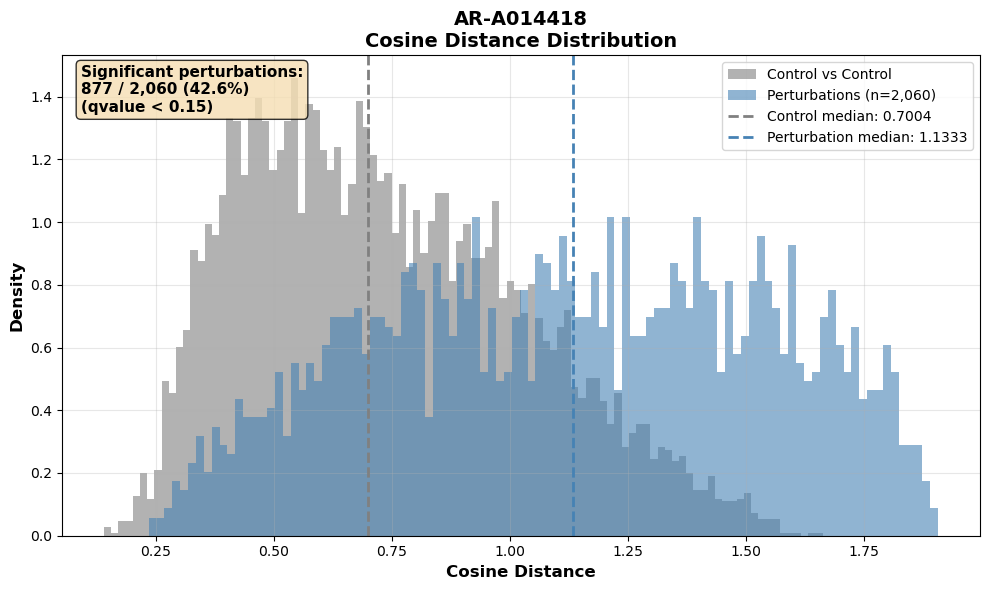


Plotting: AZD4573


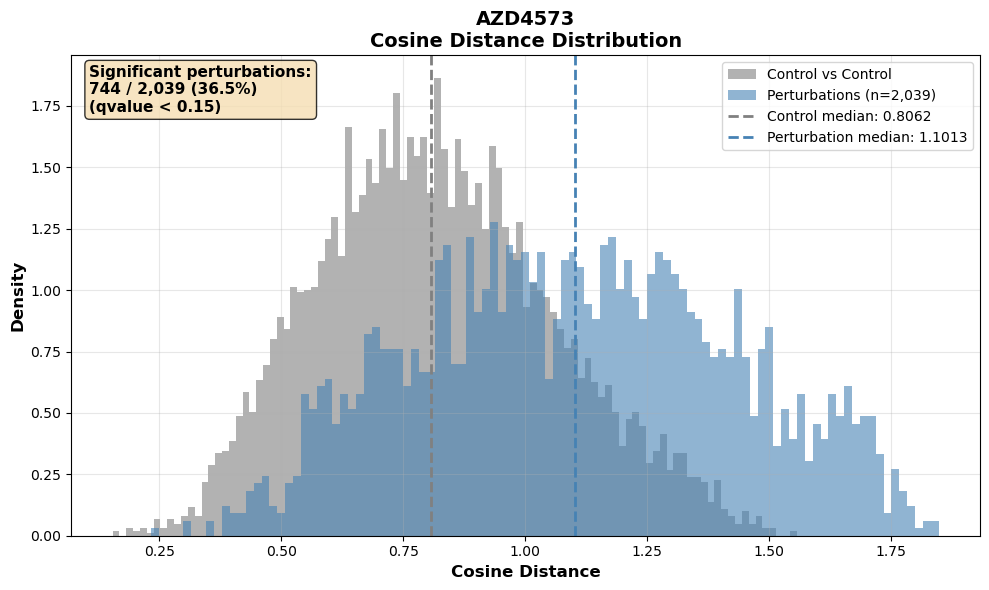


Plotting: Bisindolylmaleimide-I


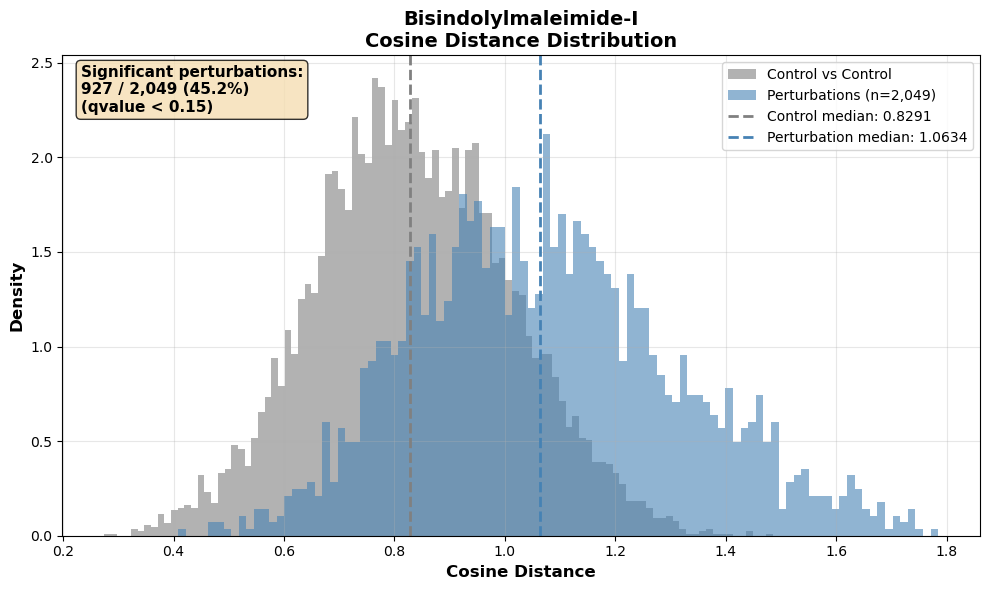


Plotting: CHIR-98014


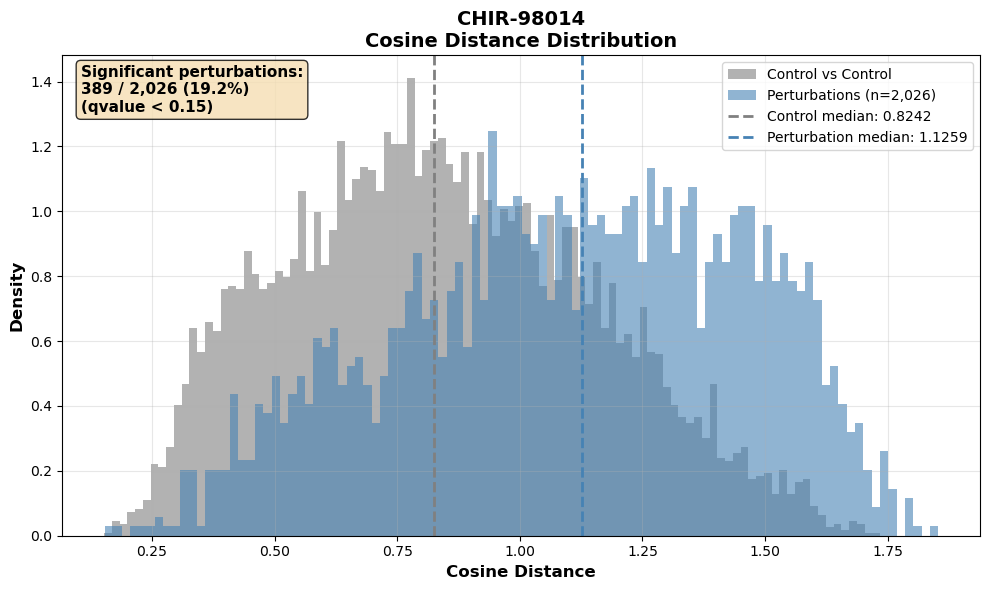


Plotting: DG-172


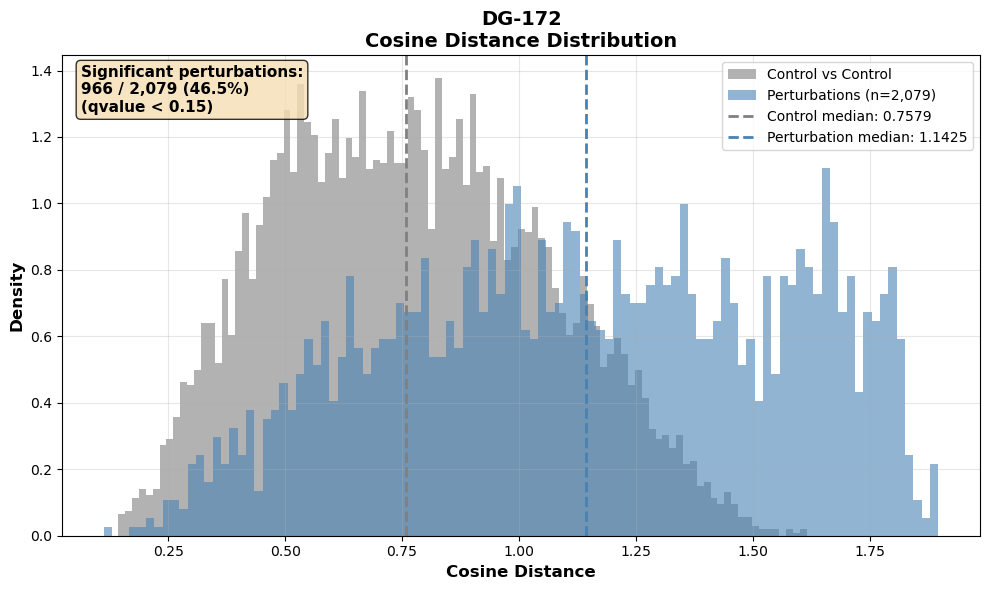


Plotting: DMSO_round2


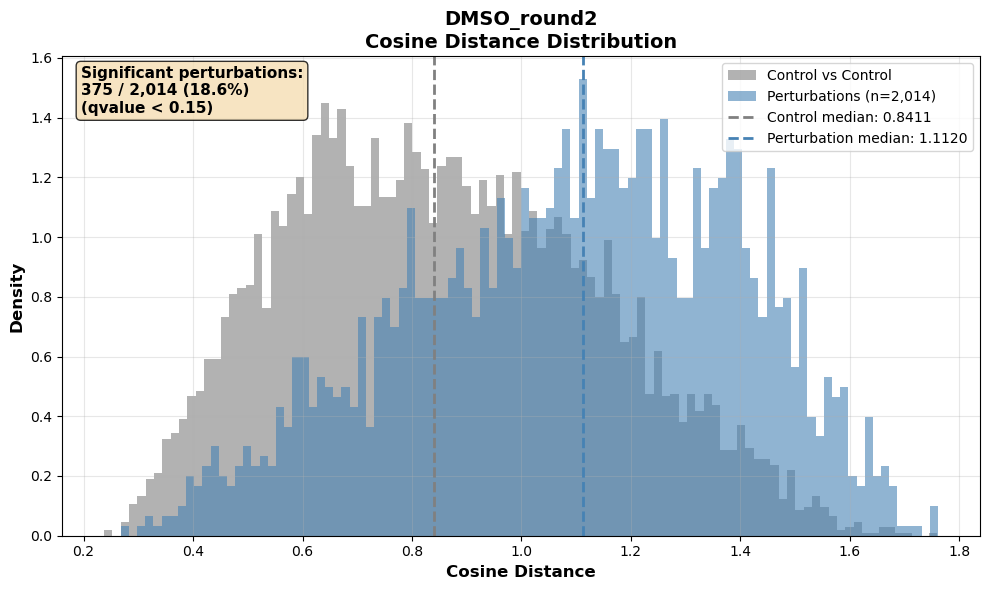


Plotting: DMSO_round2_batch2


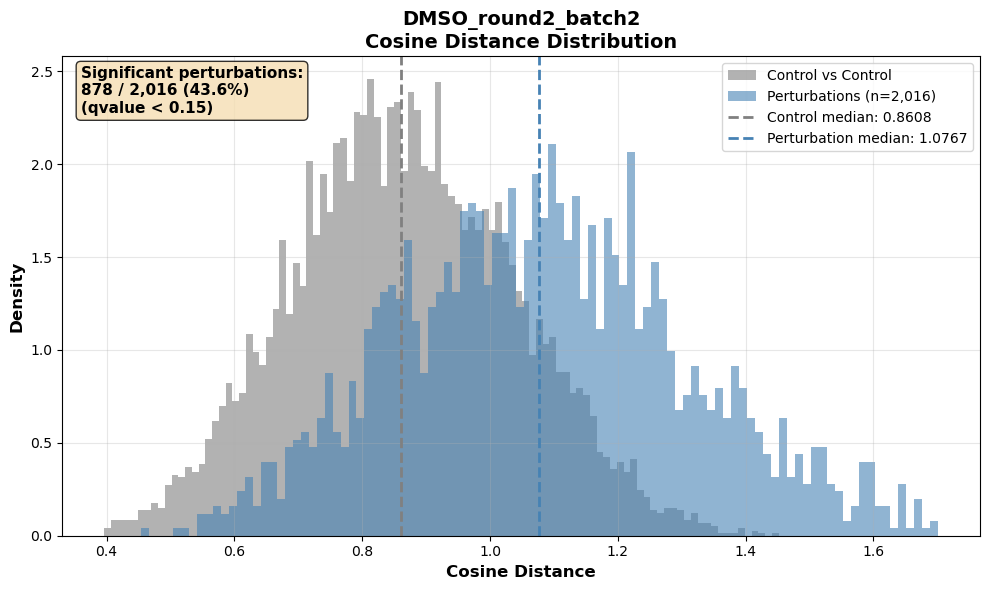


Plotting: JTE-607


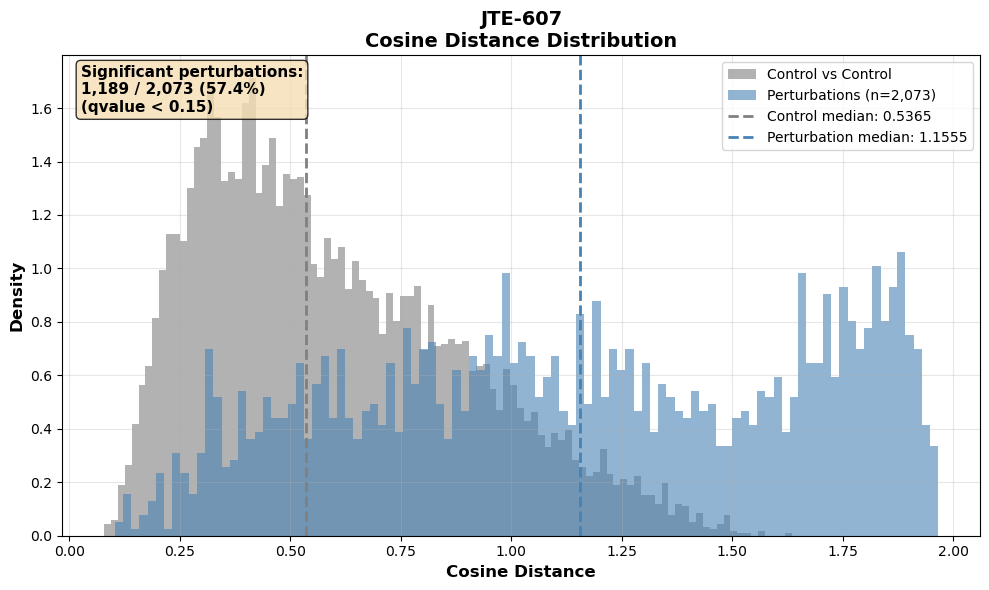


Plotting: LDN-193189


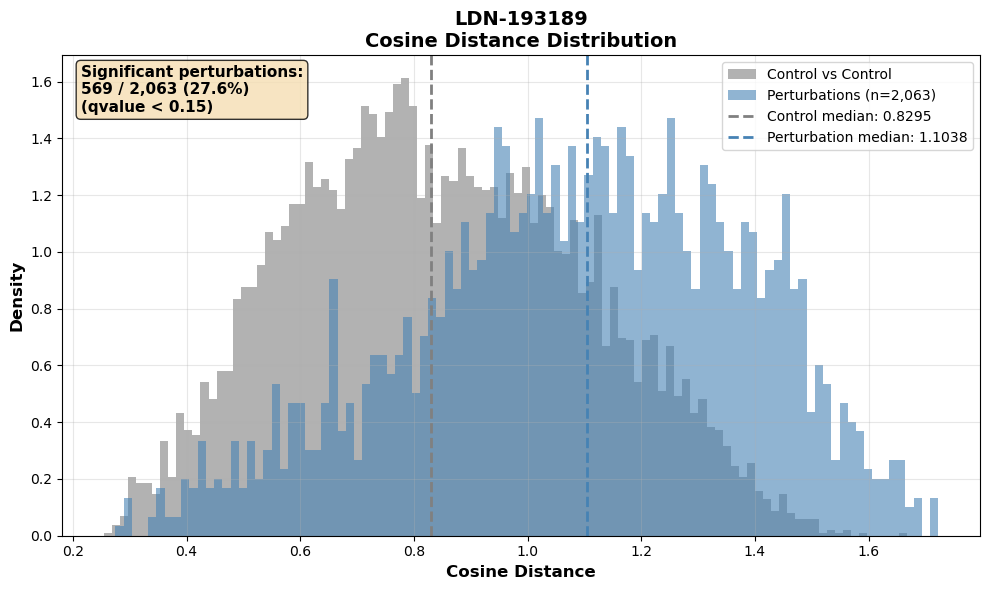


Plotting: LY2090314


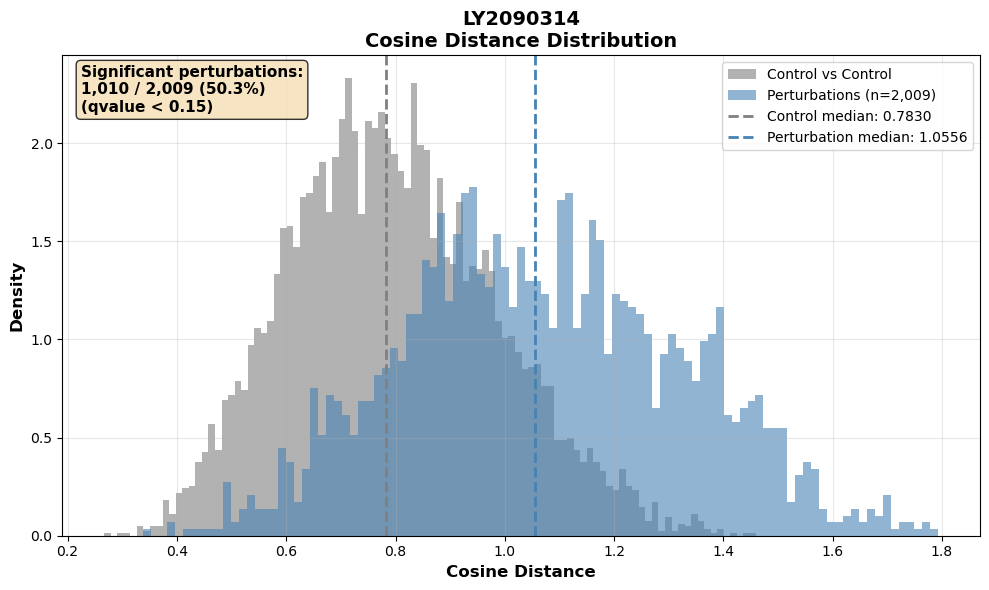


Plotting: Lexibulin


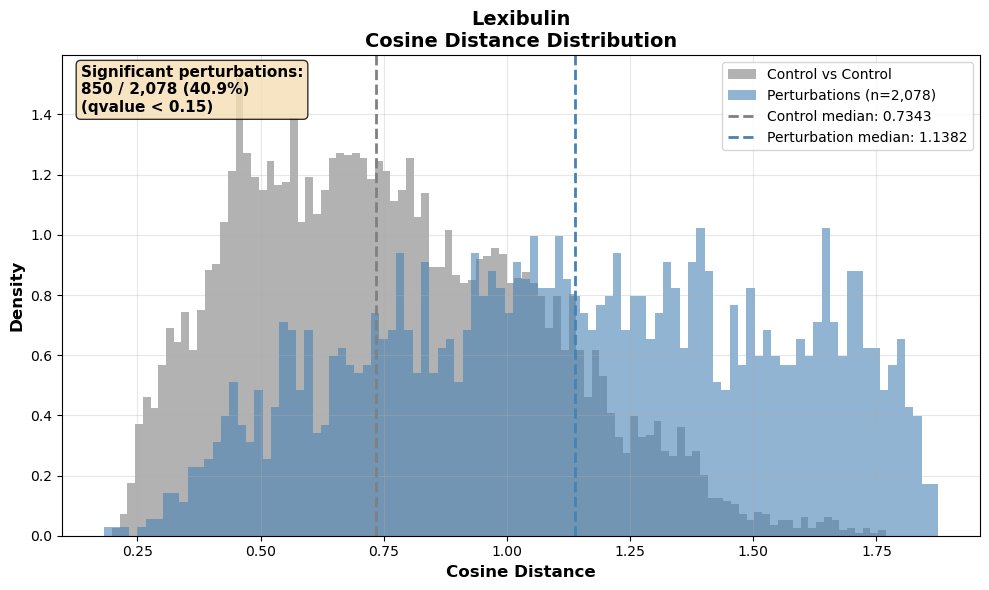


Plotting: NSC95397


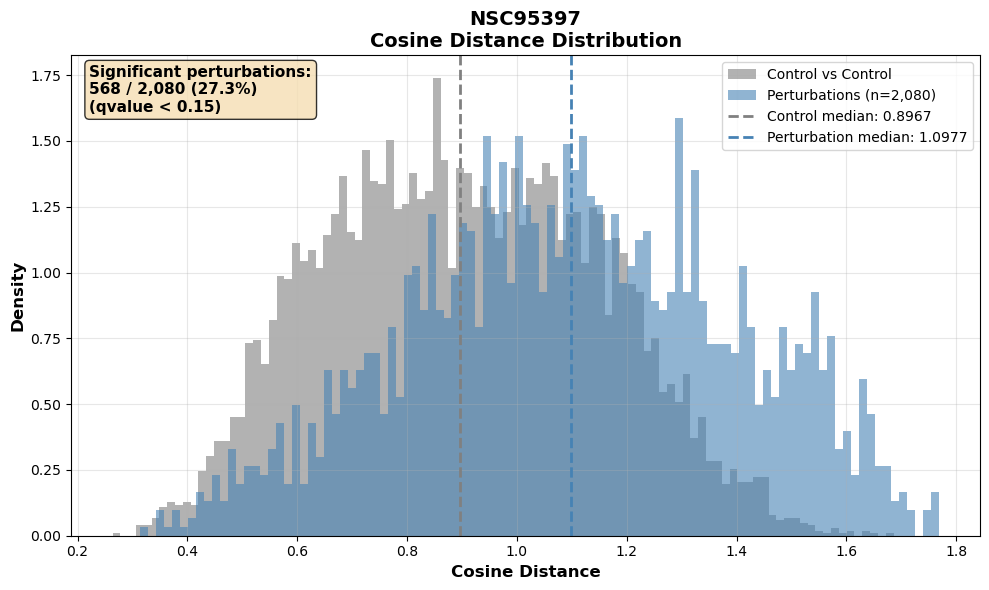


Plotting: PP121


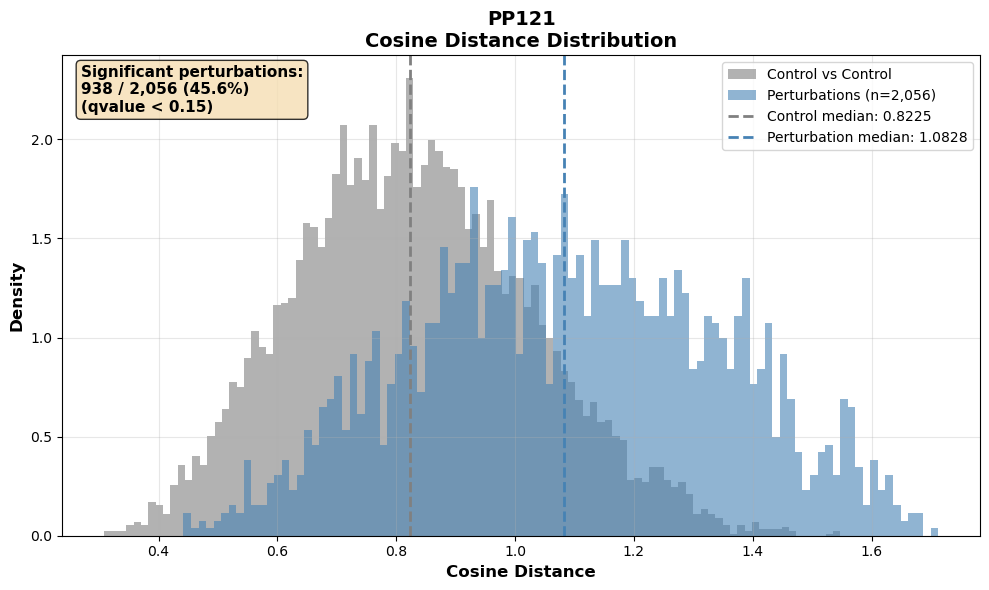


Plotting: Romidepsin


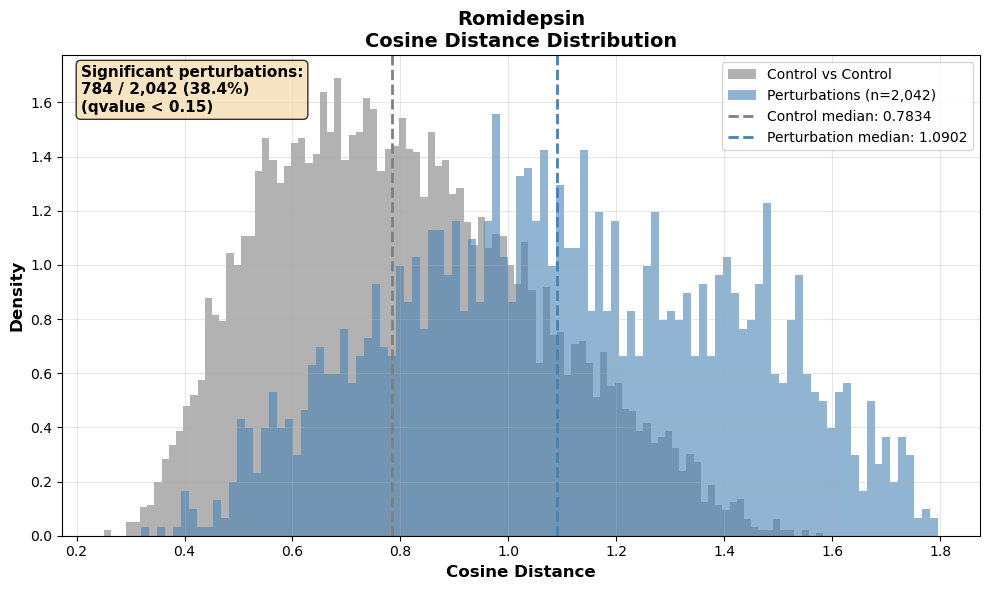


Plotting: Stattic


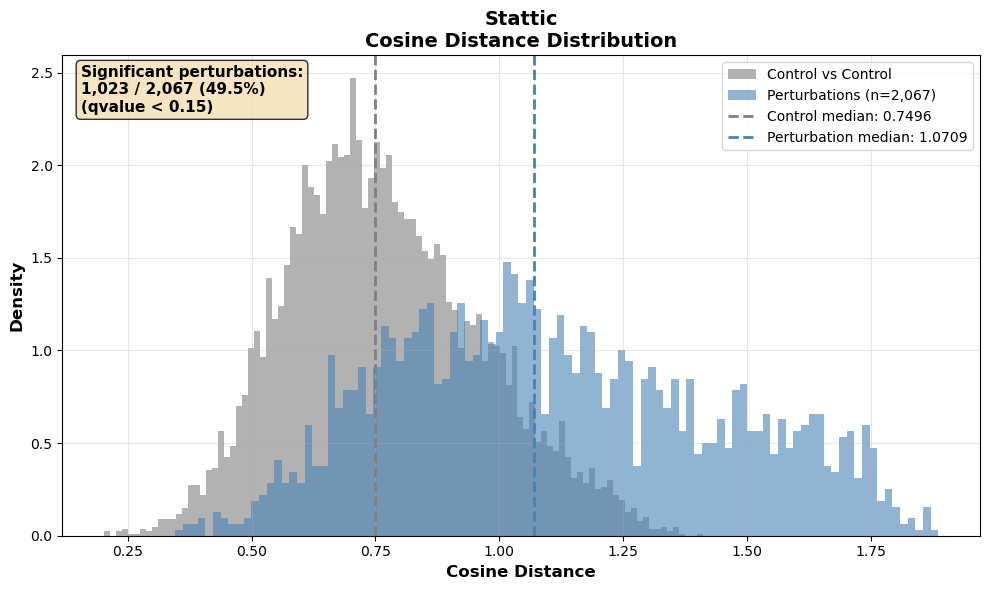


Plotting: VX-11e


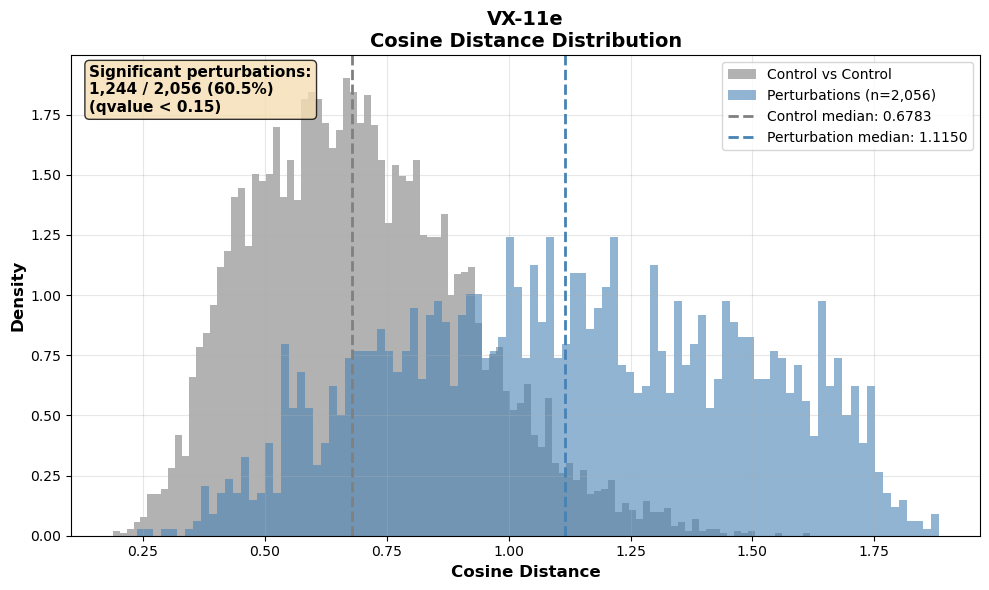


✓ Generated 16 histograms


In [23]:
plot_all_drug_histograms(
        drug_dfs=drug_dfs,
        output_dir="",
        qval_threshold=0.15,
        bins=100,
        figsize=(10, 6),
        show_plots=True,
        verbose=True
    )

In [24]:
def create_significance_matrix(
    drug_dfs: Dict[str, pd.DataFrame],
    qval_threshold: float = 0.15,
    output_file: str = "./drug_perturbation_significance_matrix.csv",
    verbose: bool = True
) -> pd.DataFrame:
    """
    Create a matrix showing which perturbations are significant in which drugs.
    
    Parameters:
    -----------
    drug_dfs : dict
        Dictionary mapping drug names to DataFrames
    qval_threshold : float
        p-value threshold for significance
    output_file : str
        Path to save matrix
    verbose : bool
        Print progress
    
    Returns:
    --------
    sig_matrix : pd.DataFrame
        Significance matrix (drugs × perturbations)
    """
    
    if verbose:
        print("\n" + "="*60)
        print("CREATING DRUG × PERTURBATION SIGNIFICANCE MATRIX")
        print("="*60)
    
    # Collect all perturbations and drugs
    all_perturbations = set()
    drug_names = []
    
    for drug_name, df in drug_dfs.items():
        drug_names.append(drug_name)
        
        # Get perturbations (exclude control_vs_control)
        perts = df[df['perturbation'] != 'control_vs_control']['perturbation'].unique()
        all_perturbations.update(perts)
    
    all_perturbations = sorted(all_perturbations)
    
    if verbose:
        print(f"\nDrugs: {len(drug_names)}")
        print(f"Perturbations: {len(all_perturbations)}")
    
    # Initialize matrix
    sig_matrix = pd.DataFrame(
        0,
        index=sorted(drug_names),
        columns=all_perturbations
    )
    
    # Fill matrix
    for drug_name, df in drug_dfs.items():
        # Get significant perturbations
        pert_df = df[df['perturbation'] != 'control_vs_control'].copy()
        
        if 'qval_cosine' not in pert_df.columns:
            if verbose:
                print(f"  WARNING: No qval_cosine column for {drug_name}, skipping")
            continue
        
        # For each perturbation, check if significant
        for pert in all_perturbations:
            pert_rows = pert_df[pert_df['perturbation'] == pert]
            
            if len(pert_rows) > 0:
                # Take minimum p-value if multiple entries
                min_qval = pert_rows['qval_cosine'].min()
                
                if min_qval < qval_threshold:
                    sig_matrix.loc[drug_name, pert] = 1
    
    # Add summary statistics
    sig_matrix['n_significant_perts'] = sig_matrix.sum(axis=1)
    
    # Add row for how many drugs each perturbation is significant in
    n_drugs_per_pert = sig_matrix.iloc[:, :-1].sum(axis=0)
    summary_row = pd.DataFrame(
        n_drugs_per_pert.values.reshape(1, -1),
        columns=n_drugs_per_pert.index,
        index=['n_drugs_significant']
    )
    summary_row['n_significant_perts'] = ''
    
    sig_matrix = pd.concat([sig_matrix, summary_row])
    
    # Save
    sig_matrix.to_csv(output_file)
    
    if verbose:
        print(f"\n✓ Significance matrix saved to: {output_file}")
        print(f"  Shape: {sig_matrix.shape}")
        
        # Summary statistics
        n_drugs = len(drug_names)
        total_tests = n_drugs * len(all_perturbations)
        total_significant = sig_matrix.iloc[:-1, :-1].sum().sum()
        
        print(f"\nSummary:")
        print(f"  Total drug-perturbation pairs: {total_tests:,}")
        print(f"  Significant pairs: {total_significant:,} ({total_significant/total_tests*100:.1f}%)")
        
        # Most commonly significant perturbations
        top_perts = n_drugs_per_pert.nlargest(10)
        if len(top_perts) > 0:
            print(f"\nTop 10 perturbations (significant in most drugs):")
            for pert, count in top_perts.items():
                print(f"  {pert}: {count}/{n_drugs} drugs ({count/n_drugs*100:.0f}%)")
    
    return sig_matrix

sig_matrix = create_significance_matrix(
        drug_dfs=drug_dfs,
        qval_threshold=0.15,
        output_file="/home/beraslan/Projects/ChemoGeneticScreens/PertSignificance/drug_perturbation_significance_matrix.csv",
        verbose=True
    )


CREATING DRUG × PERTURBATION SIGNIFICANCE MATRIX

Drugs: 16
Perturbations: 2125

✓ Significance matrix saved to: /home/beraslan/Projects/ChemoGeneticScreens/PertSignificance/drug_perturbation_significance_matrix.csv
  Shape: (17, 2126)

Summary:
  Total drug-perturbation pairs: 34,000
  Significant pairs: 13,331 (39.2%)

Top 10 perturbations (significant in most drugs):
  COX6C: 16/16 drugs (100%)
  CSNK1E: 16/16 drugs (100%)
  CTPS1: 16/16 drugs (100%)
  CTTN: 16/16 drugs (100%)
  CYCS: 16/16 drugs (100%)
  DDX31: 16/16 drugs (100%)
  DHX36: 16/16 drugs (100%)
  DHX9: 16/16 drugs (100%)
  DLG5: 16/16 drugs (100%)
  DLGAP5: 16/16 drugs (100%)


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


mat = sig_matrix.iloc[0:16,0:2124]


baseline_rows = ["DMSO_round2", "DMSO_round2_batch2"]

baseline = mat.loc[baseline_rows].max(axis=0)

# remove old baseline rows
mat = mat.drop(baseline_rows)

# add merged baseline
mat.loc["DMSO_baseline"] = baseline

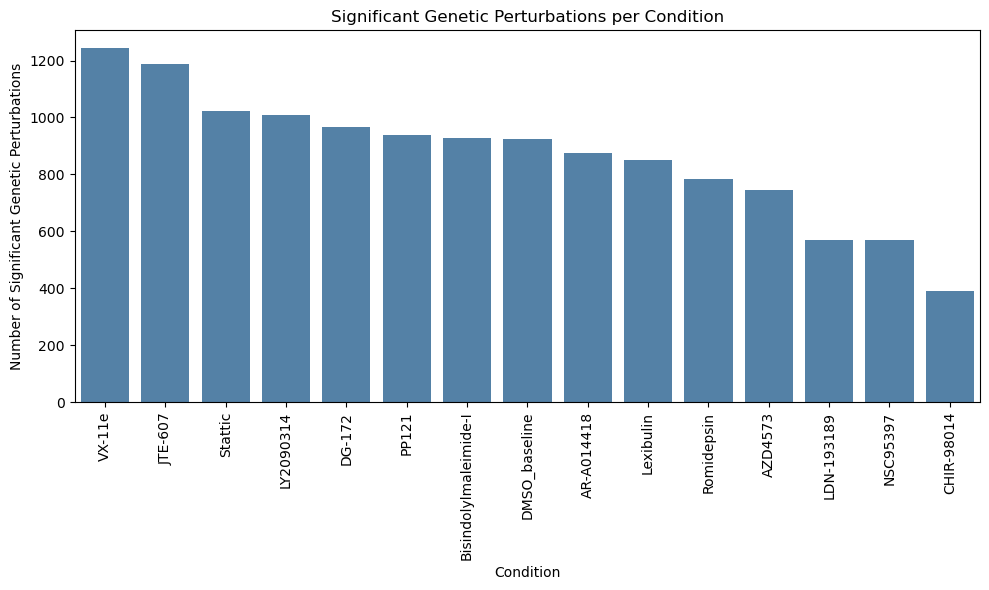

In [26]:
sig_counts = mat.sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=sig_counts.index,
    y=sig_counts.values,
    color="steelblue"
)

plt.xticks(rotation=90)
plt.ylabel("Number of Significant Genetic Perturbations")
plt.xlabel("Condition")
plt.title("Significant Genetic Perturbations per Condition")

plt.tight_layout()
plt.show()

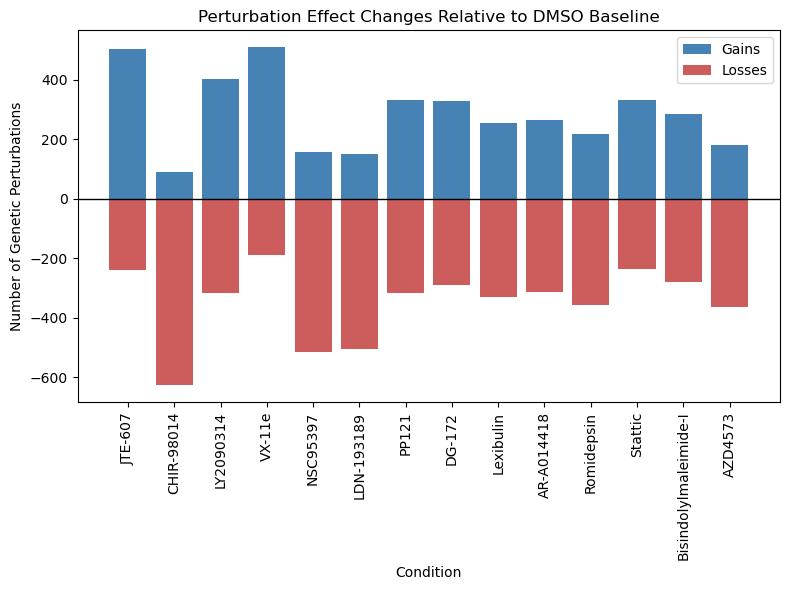

In [27]:
baseline_conditions = ["DMSO_baseline"]

# Combine baseline
baseline = mat.loc[baseline_conditions].max(axis=0)

gain_counts = {}
loss_counts = {}

for cond in mat.index:
    if cond in baseline_conditions:
        continue

    cond_vec = mat.loc[cond]

    gains = ((cond_vec == 1) & (baseline == 0)).sum()
    losses = ((cond_vec == 0) & (baseline == 1)).sum()

    gain_counts[cond] = gains
    loss_counts[cond] = losses

df_plot = pd.DataFrame({
    "condition": list(gain_counts.keys()),
    "gains": list(gain_counts.values()),
    "losses": list(loss_counts.values())
})

# sort by total change
df_plot["total"] = df_plot["gains"] + df_plot["losses"]
df_plot = df_plot.sort_values("total", ascending=False)

# -----------------------
# Plot
# -----------------------

plt.figure(figsize=(8,6))

plt.bar(df_plot["condition"], df_plot["gains"], label="Gains", color="steelblue")
plt.bar(df_plot["condition"], -df_plot["losses"], label="Losses", color="indianred")

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)

plt.ylabel("Number of Genetic Perturbations")
plt.xlabel("Condition")
plt.title("Perturbation Effect Changes Relative to DMSO Baseline")

plt.legend()

plt.tight_layout()
plt.show()

In [38]:
def plot_cumulative_perturbation_significance(
    sig_matrix: pd.DataFrame,
    figsize: Tuple[int, int] = (12, 7),
    show_plot: bool = True
):
    """
    Plot cumulative number of perturbations significant in N drugs.
    
    Shows:
    - How many perturbations are significant in at least 1, 2, 3, ... N drugs
    - Bar chart and cumulative line
    
    Parameters:
    -----------
    sig_matrix : pd.DataFrame
        Binary significance matrix (drugs × perturbations)
    figsize : tuple
        Figure size
    show_plot : bool
        Whether to display plot
    """
    
    # Remove summary row if present
    if 'n_drugs_significant' in sig_matrix.index:
        sig_matrix_clean = sig_matrix.drop('n_drugs_significant')
    else:
        sig_matrix_clean = sig_matrix.copy()
    
    # Remove summary column if present
    if 'n_significant_perts' in sig_matrix_clean.columns:
        sig_matrix_clean = sig_matrix_clean.drop('n_significant_perts', axis=1)
    
    # Count how many drugs each perturbation is significant in
    n_drugs_per_pert = sig_matrix_clean.sum(axis=0)
    
    # Count how many perturbations are significant in exactly N drugs
    value_counts = n_drugs_per_pert.value_counts().sort_index()
    
    # Calculate cumulative (at least N drugs)
    n_drugs = len(sig_matrix_clean)
    cumulative = {}
    
    for n in range(1, n_drugs + 1):
        cumulative[n] = (n_drugs_per_pert >= n).sum()
    
    cumulative_df = pd.DataFrame(list(cumulative.items()), columns=['n_drugs', 'n_perturbations'])
    
    # Create plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # === Left plot: Bar chart (exactly N drugs) ===
    ax = axes[0]
    
    if len(value_counts) > 0:
        bars = ax.bar(value_counts.index, value_counts.values, 
                     color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Number of Drugs', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Perturbations', fontsize=12, fontweight='bold')
    ax.set_title('Perturbations Significant in Exactly N Drugs', 
                fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(range(1, n_drugs + 1))
    
    # === Right plot: Cumulative (at least N drugs) ===
    ax = axes[1]
    
    ax.plot(cumulative_df['n_drugs'], cumulative_df['n_perturbations'], 
           marker='o', linewidth=3, markersize=8, color='coral')
    ax.fill_between(cumulative_df['n_drugs'], cumulative_df['n_perturbations'], 
                    alpha=0.3, color='coral')
    
    # Add value labels
    for _, row in cumulative_df.iterrows():
        if row['n_perturbations'] > 0:
            ax.text(row['n_drugs'], row['n_perturbations'] + cumulative_df['n_perturbations'].max() * 0.02,
                   f"{int(row['n_perturbations'])}",
                   ha='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Minimum Number of Drugs', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Perturbations', fontsize=12, fontweight='bold')
    ax.set_title('Perturbations Significant in ≥ N Drugs\n(Cumulative)', 
                fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xticks(range(1, n_drugs + 1))
    ax.set_xlim(0.5, n_drugs + 0.5)
    
    # Add summary text
    total_perts = len(sig_matrix_clean.columns)
    n_sig_any = (n_drugs_per_pert > 0).sum()
    n_sig_all = (n_drugs_per_pert == n_drugs).sum()
    
    summary_text = f"""Summary:
Total perturbations: {total_perts}
Significant in any drug: {n_sig_any} ({n_sig_any/total_perts*100:.1f}%)
Significant in all drugs: {n_sig_all} ({n_sig_all/total_perts*100:.1f}% if total_perts > 0 else 0)"""
    
    fig.text(0.5, 0.02, summary_text, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    
    
   
    plt.show()
    
    return cumulative_df



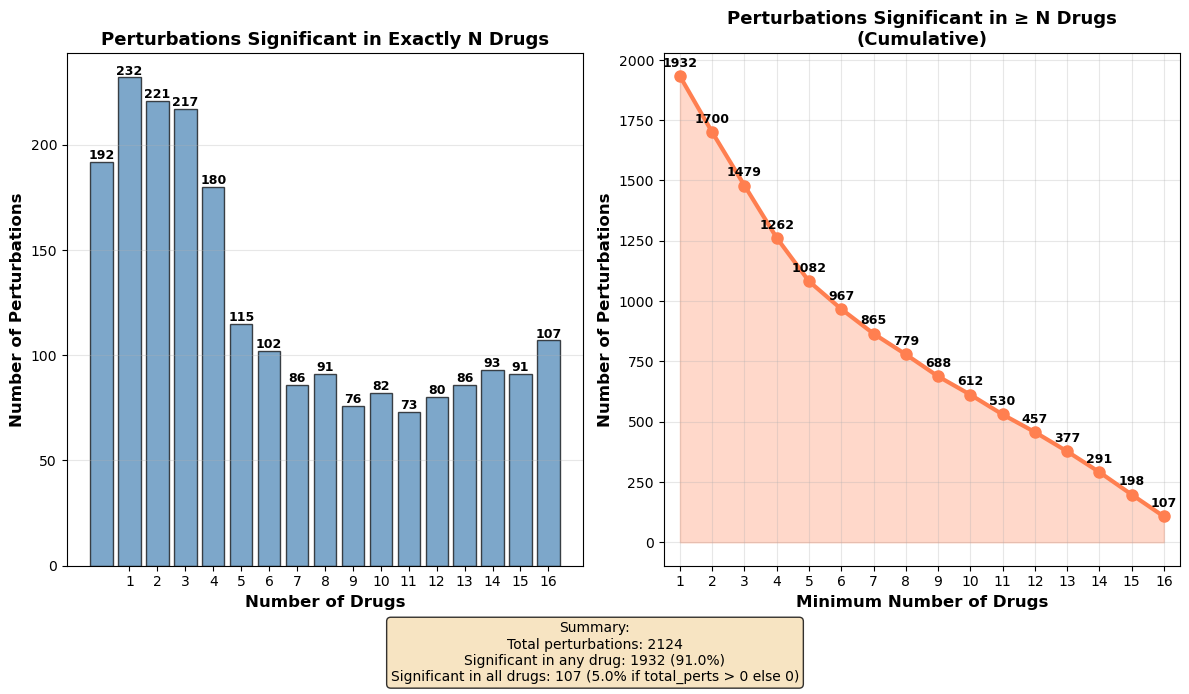

,n_drugs,n_perturbations
0,1,1932
1,2,1700
2,3,1479
3,4,1262
4,5,1082
5,6,967
6,7,865
7,8,779
8,9,688
9,10,612


In [39]:
plot_cumulative_perturbation_significance(
    sig_matrix=sig_matrix.iloc[0:16,0:2124],
)

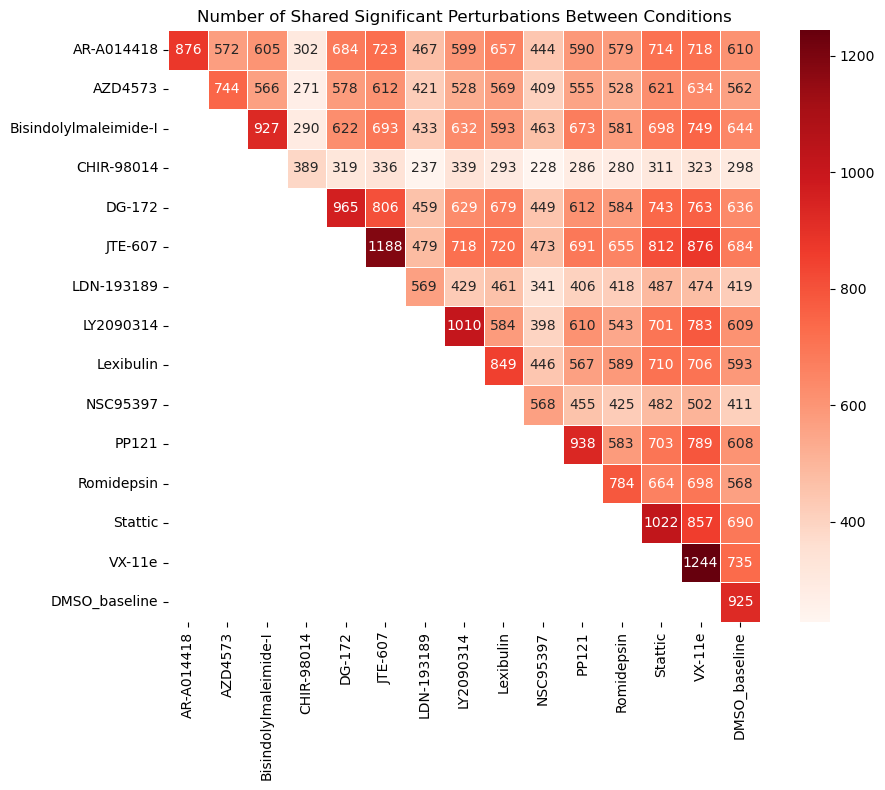

In [40]:
conditions = mat.index
n = len(conditions)

overlap = pd.DataFrame(
    np.zeros((n, n)),
    index=conditions,
    columns=conditions
)

for i in conditions:
    for j in conditions:
        overlap.loc[i, j] = np.sum((mat.loc[i] == 1) & (mat.loc[j] == 1))

# Mask lower triangle
mask = np.tril(np.ones_like(overlap, dtype=bool), k=-1)

plt.figure(figsize=(10,8))

sns.heatmap(
    overlap,
    mask=mask,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    square=True
)

plt.title("Number of Shared Significant Perturbations Between Conditions")

plt.tight_layout()
plt.show()

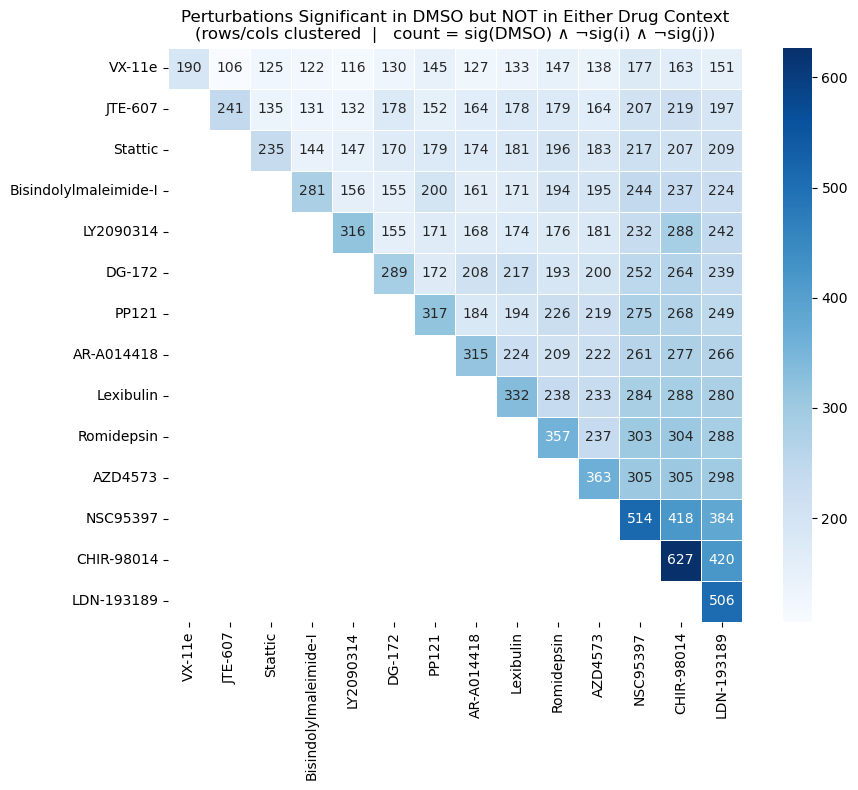

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Heatmap: # of perturbations significant in DMSO but NOT significant in
# EITHER of two non-DMSO drug contexts (the pair). Upper triangular.
# Rows/cols ordered by hierarchical clustering on the symmetric count matrix.
DMSO_LABEL = "DMSO_baseline"
non_dmso = [c for c in mat.index if c != DMSO_LABEL]

dmso_sig = mat.loc[DMSO_LABEL].astype(bool)

n = len(non_dmso)
dmso_only = pd.DataFrame(
    np.zeros((n, n), dtype=int),
    index=non_dmso,
    columns=non_dmso,
)
for i in non_dmso:
    for j in non_dmso:
        # significant in DMSO, NOT significant in i, NOT significant in j
        cond = dmso_sig & (~mat.loc[i].astype(bool)) & (~mat.loc[j].astype(bool))
        dmso_only.loc[i, j] = int(cond.sum())

# Cluster on the SYMMETRIC count matrix.
# Convert similarity → distance (use max - sim) then run average-linkage.
sim = dmso_only.values.astype(float)
dist = sim.max() - sim
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
order = [non_dmso[i] for i in leaves_list(Z)]
dmso_only = dmso_only.loc[order, order]

mask = np.tril(np.ones_like(dmso_only, dtype=bool), k=-1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    dmso_only,
    mask=mask,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    square=True,
)
plt.title(
    "Perturbations Significant in DMSO but NOT in Either Drug Context\n"
    "(rows/cols clustered  |   count = sig(DMSO) ∧ ¬sig(i) ∧ ¬sig(j))"
)
plt.tight_layout()
plt.show()


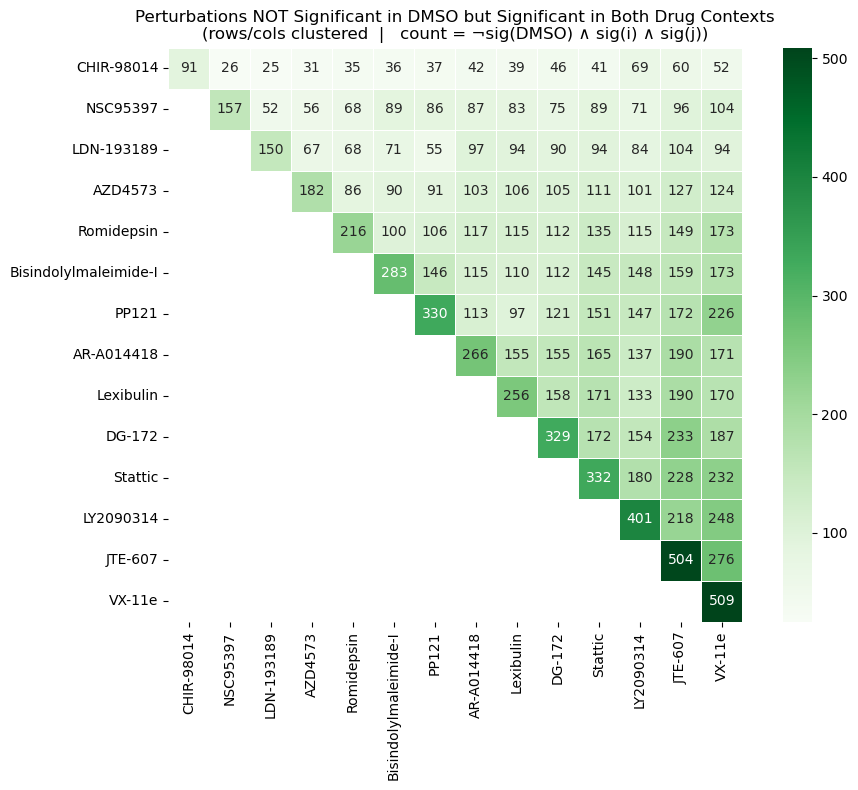

In [42]:
# Heatmap: # of perturbations NOT significant in DMSO but significant in
# BOTH of two non-DMSO drug contexts. Upper triangular, clustered.
non_dmso_sig = (~dmso_sig)   # bool: not sig in DMSO

drug_only = pd.DataFrame(
    np.zeros((n, n), dtype=int),
    index=non_dmso,
    columns=non_dmso,
)
for i in non_dmso:
    for j in non_dmso:
        cond = non_dmso_sig & mat.loc[i].astype(bool) & mat.loc[j].astype(bool)
        drug_only.loc[i, j] = int(cond.sum())

# Cluster on the SYMMETRIC count matrix
sim = drug_only.values.astype(float)
dist = sim.max() - sim
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
order = [non_dmso[i] for i in leaves_list(Z)]
drug_only = drug_only.loc[order, order]

mask = np.tril(np.ones_like(drug_only, dtype=bool), k=-1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    drug_only,
    mask=mask,
    cmap="Greens",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    square=True,
)
plt.title(
    "Perturbations NOT Significant in DMSO but Significant in Both Drug Contexts\n"
    "(rows/cols clustered  |   count = ¬sig(DMSO) ∧ sig(i) ∧ sig(j))"
)
plt.tight_layout()
plt.show()


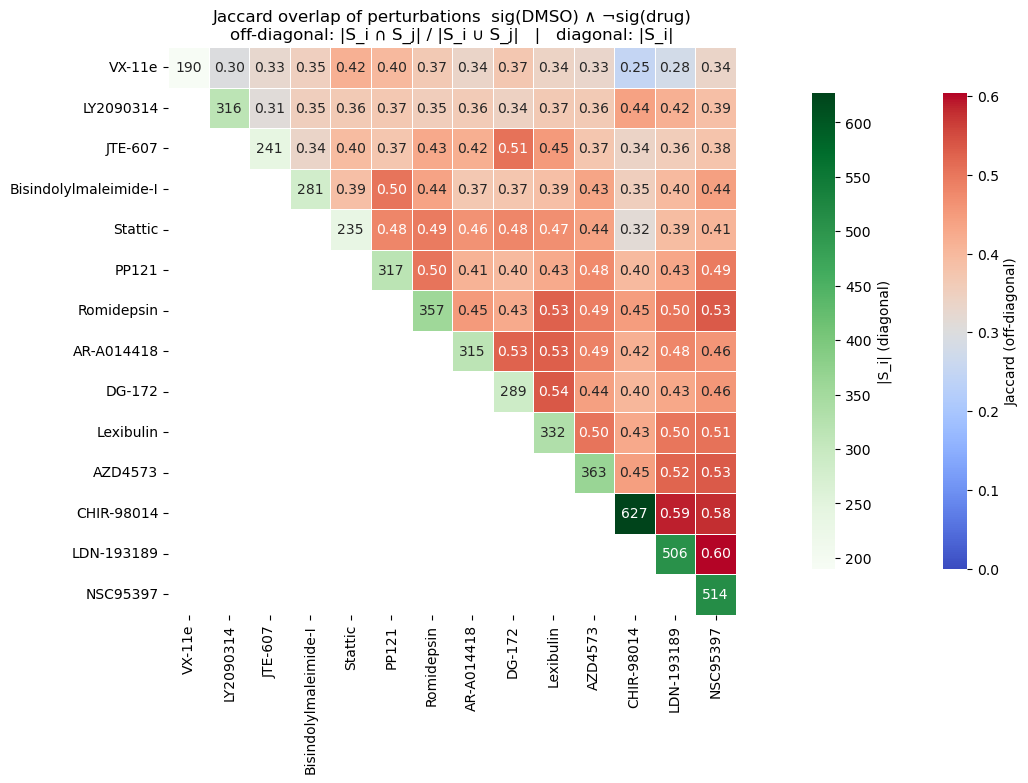

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Jaccard view of the "sig in DMSO, NOT sig in either drug" relation.
# For each condition c, define the set
#     S_c = { perturbations P : sig(DMSO, P) ∧ ¬sig(c, P) }
# Off-diagonal cell (i, j)  =  |S_i ∩ S_j| / |S_i ∪ S_j|
# Diagonal cell    (i, i)   =  |S_i|  (raw count, drawn with a different cmap)

DMSO_LABEL = "DMSO_baseline"
non_dmso = [c for c in mat.index if c != DMSO_LABEL]
n = len(non_dmso)
dmso_sig = mat.loc[DMSO_LABEL].astype(bool)

# Per-drug sets
sets = {
    d: set(mat.columns[(dmso_sig & ~mat.loc[d].astype(bool)).values])
    for d in non_dmso
}

jacc = pd.DataFrame(np.zeros((n, n)), index=non_dmso, columns=non_dmso)
diag_counts = pd.DataFrame(np.zeros((n, n)), index=non_dmso, columns=non_dmso)
for i in non_dmso:
    for j in non_dmso:
        if i == j:
            diag_counts.loc[i, i] = len(sets[i])
        else:
            inter = len(sets[i] & sets[j])
            union = len(sets[i] | sets[j])
            jacc.loc[i, j] = inter / union if union > 0 else np.nan

# Cluster on the symmetric Jaccard matrix (off-diagonal only)
sim = jacc.values.copy()
np.fill_diagonal(sim, np.nanmax(sim))   # diagonal = max similarity for clustering
dist = np.nanmax(sim) - sim
dist = np.nan_to_num(dist, nan=np.nanmax(dist))
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
order = [non_dmso[i] for i in leaves_list(Z)]
jacc = jacc.loc[order, order]
diag_counts = diag_counts.loc[order, order]

# Masks
upper_offdiag_mask = np.tril(np.ones((n, n), bool), k=0)            # show only upper, no diagonal
diag_only_mask     = ~np.eye(n, dtype=bool)                          # show only diagonal

fig, ax = plt.subplots(figsize=(11, 9))

# Off-diagonal Jaccard
sns.heatmap(
    jacc, mask=upper_offdiag_mask,
    cmap="coolwarm", vmin=0, vmax=jacc.values[~np.eye(n, dtype=bool)].max(),
    annot=True, fmt=".2f",
    linewidths=0.5, square=True,
    cbar_kws={"label": "Jaccard (off-diagonal)", "shrink": 0.6, "pad": 0.02},
    ax=ax,
)

# Diagonal raw counts (different cmap)
sns.heatmap(
    diag_counts, mask=diag_only_mask,
    cmap="Greens",
    annot=True, fmt=".0f",
    linewidths=0.5, square=True,
    cbar_kws={"label": "|S_i| (diagonal)", "shrink": 0.6, "pad": 0.10},
    ax=ax,
)

ax.set_title(
    "Jaccard overlap of perturbations  sig(DMSO) ∧ ¬sig(drug)\n"
    "off-diagonal: |S_i ∩ S_j| / |S_i ∪ S_j|   |   diagonal: |S_i|"
)
plt.tight_layout()
plt.show()


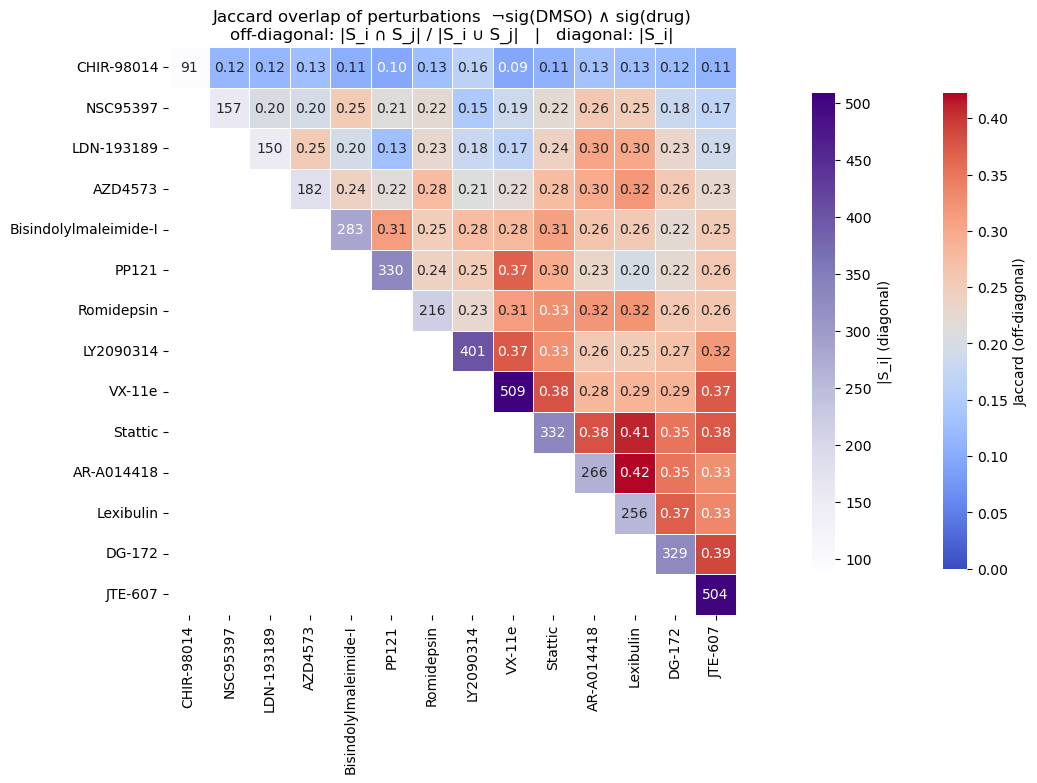

In [48]:
# Jaccard view of the "NOT sig in DMSO, sig in drug" relation.
# Set: S_c = { perturbations P : ¬sig(DMSO, P) ∧ sig(c, P) }

non_dmso_sig = ~dmso_sig

sets2 = {
    d: set(mat.columns[(non_dmso_sig & mat.loc[d].astype(bool)).values])
    for d in non_dmso
}

jacc2 = pd.DataFrame(np.zeros((n, n)), index=non_dmso, columns=non_dmso)
diag_counts2 = pd.DataFrame(np.zeros((n, n)), index=non_dmso, columns=non_dmso)
for i in non_dmso:
    for j in non_dmso:
        if i == j:
            diag_counts2.loc[i, i] = len(sets2[i])
        else:
            inter = len(sets2[i] & sets2[j])
            union = len(sets2[i] | sets2[j])
            jacc2.loc[i, j] = inter / union if union > 0 else np.nan

# Cluster on Jaccard
sim = jacc2.values.copy()
np.fill_diagonal(sim, np.nanmax(sim))
dist = np.nanmax(sim) - sim
dist = np.nan_to_num(dist, nan=np.nanmax(dist))
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method='average')
order = [non_dmso[i] for i in leaves_list(Z)]
jacc2 = jacc2.loc[order, order]
diag_counts2 = diag_counts2.loc[order, order]

upper_offdiag_mask = np.tril(np.ones((n, n), bool), k=0)
diag_only_mask     = ~np.eye(n, dtype=bool)

fig, ax = plt.subplots(figsize=(11, 9))

# Off-diagonal Jaccard
sns.heatmap(
    jacc2, mask=upper_offdiag_mask,
    cmap="coolwarm", vmin=0, vmax=jacc2.values[~np.eye(n, dtype=bool)].max(),
    annot=True, fmt=".2f",
    linewidths=0.5, square=True,
    cbar_kws={"label": "Jaccard (off-diagonal)", "shrink": 0.6, "pad": 0.02},
    ax=ax,
)

# Diagonal raw counts
sns.heatmap(
    diag_counts2, mask=diag_only_mask,
    cmap="Purples",
    annot=True, fmt=".0f",
    linewidths=0.5, square=True,
    cbar_kws={"label": "|S_i| (diagonal)", "shrink": 0.6, "pad": 0.10},
    ax=ax,
)

ax.set_title(
    "Jaccard overlap of perturbations  ¬sig(DMSO) ∧ sig(drug)\n"
    "off-diagonal: |S_i ∩ S_j| / |S_i ∪ S_j|   |   diagonal: |S_i|"
)
plt.tight_layout()
plt.show()


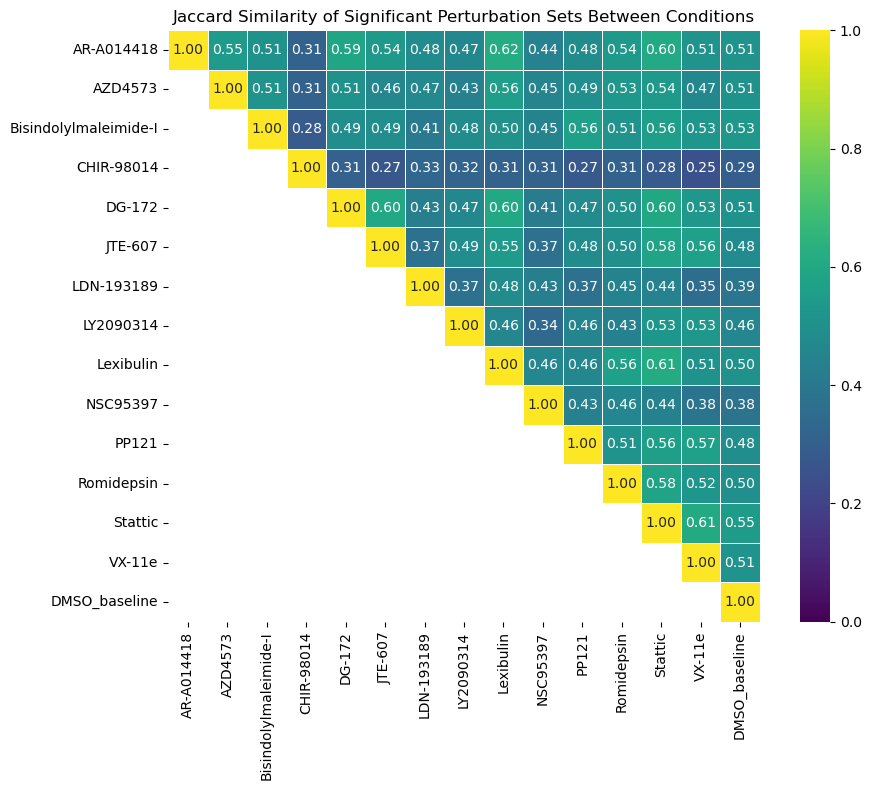

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# mat:
# rows = conditions
# columns = perturbation identities
# values = 0/1

# Build a set of significant perturbation identities for each condition
pert_sets = {
    cond: set(mat.columns[mat.loc[cond].astype(bool)])
    for cond in mat.index
}

# Compute Jaccard similarity matrix
conditions = list(mat.index)
jaccard_df = pd.DataFrame(
    np.zeros((len(conditions), len(conditions))),
    index=conditions,
    columns=conditions,
    dtype=float,
)

for c1 in conditions:
    for c2 in conditions:
        inter = len(pert_sets[c1] & pert_sets[c2])
        union = len(pert_sets[c1] | pert_sets[c2])
        jaccard_df.loc[c1, c2] = inter / union if union > 0 else np.nan

# Plot only upper triangle
mask = np.tril(np.ones_like(jaccard_df, dtype=bool), k=-1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    jaccard_df,
    mask=mask,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
)

plt.title("Jaccard Similarity of Significant Perturbation Sets Between Conditions")
plt.tight_layout()
plt.show()

## Save the union of perturbations significant in ≥1 drug context

Single-column CSV consumed downstream by notebooks 10 / 11 / 12 — they read
this list rather than recomputing it from `sig_matrix`.

Output: `PertSignificance/union_significant_perts.csv`

In [ ]:
from pathlib import Path

# Drop summary col/row if present, then count drugs per pert
sig_data = sig_matrix.drop(columns=['n_significant_perts'], errors='ignore') \
                     .drop(index='n_drugs_significant',    errors='ignore')
n_drugs_sig = (sig_data > 0).sum(axis=0)

union_perts = sorted(n_drugs_sig[n_drugs_sig >= 1].index.tolist())
print(f'Union of perts sig (q-cosine < 0.15) in ≥1 drug: {len(union_perts):,}')

union_path = Path('/home/beraslan/Projects/ChemoGeneticScreens/PertSignificance/union_significant_perts.csv')
union_path.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame({'perturbation': union_perts}).to_csv(union_path, index=False)
print(f'Saved → {union_path}')

In [ ]:
union_perts